## Tree Volume Prediction

#### Import all relevant libraries

In [4]:
import os
from dotenv import load_dotenv

import psycopg2
from sqlalchemy import create_engine, inspect

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

In [5]:
load_dotenv()

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

# connection string
conn_str = f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'

# connect to database
engine = create_engine(conn_str)

In [6]:
# Display tables and various column names of the dataset
def display_tables_columns(conn):
    inspector = inspect(conn)

    # Get all table names
    table_names = inspector.get_table_names()

    print("TABLE NAMES")
    print("-"*30)

    for table in table_names:
        print(table)

    print("\n")
    print("COLUMN NAMES")
    print("-"*30)

    # Get all column names of the tables
    for table_name in table_names:
        columns = inspector.get_columns(table_name)
        names = [column['name'] for column in columns]
        print(f"{table_name} columns:\n{names}\n\n")

In [8]:
# Query the Database to retrieve the relevant data from the tables
query = """
    SELECT 
        b.plantation,
        p.block,
        b."year planted",
        b."block area (ha)",
        p.plot,
        pmh."Default plot size",
        pmh."plot type",
        d.area_type,
        d."monitoring year",
        d.tree_id,
        d."Tree SPECIES",
        d.height_m,
        d.dbh_cm,
        d.remarks
    FROM block_register b
    JOIN plot_bloc_relation p
        ON p.plantation = b.plantation
        AND p.block = b.block
    JOIN plot_monitoring_history pmh
        ON pmh.plantation = p.plantation
        AND pmh.plot = p.plot
    JOIN tree_data d
        ON d.plantation = p.plantation
        AND d.plot = p.plot
    WHERE d.area_type = 'Teak';
"""

def retrieve_data(query, conn):
    df = pd.read_sql_query(query, conn)

    return df

In [9]:
display_tables_columns(engine)

TABLE NAMES
------------------------------
block_register
plot_monitoring_history
psps
slope_correction_factors
thinning_history
tree_data
plot_bloc_relation


COLUMN NAMES
------------------------------
block_register columns:
['plantation', 'block', 'status', 'rotation', 'ownership', 'reserve', 'year planted', 'block area (ha)', 'productive', 'unproductive', 'Teak', 'NATURAL INDIGENOUS', 'PLANTED INDIGENOUS', 'GMELINA', 'OPEN LAND', 'ROCK', 'remarks']


plot_monitoring_history columns:
['MonitoringID', 'plantation', 'plot', 'area_type', 'monitoring year', 'monitoring Month', 'monitoring day', 'Default plot size', 'plot type', 'Monitoring team', 'Shrub cover (%)', 'Herb cover (%)', 'Invasive species cover (%)', 'Erosion', 'Remarks', 'Excluded', 'Justification for exclusion', 'MDate']


psps columns:
['ID', 'plantation', 'reserve', 'plot', 'Coord_X', 'Coord_Y', 'Provenance', 'Initial N/ha', 'Soil depth', 'Soil inclination (degrees)', 'Lost plot', 'remarks', 'Slope']


slope_correction_

In [10]:
df = retrieve_data(query, engine)
df.head()

,plantation,block,year planted,block area (ha),plot,Default plot size,plot type,area_type,monitoring year,tree_id,Tree SPECIES,height_m,dbh_cm,remarks
0,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars
1,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars
2,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars
3,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars
4,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars


In [11]:
# Data Information

print(df.shape)
print("-"*30)
print(df.info())
print("-"*30)
print(df.isna().sum())

(2144445, 14)
------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 2144445 entries, 0 to 2144444
Data columns (total 14 columns):
 #   Column             Dtype  
---  ------             -----  
 0   plantation         str    
 1   block              str    
 2   year planted       int64  
 3   block area (ha)    float64
 4   plot               str    
 5   Default plot size  float64
 6   plot type          str    
 7   area_type          str    
 8   monitoring year    float64
 9   tree_id            float64
 10  Tree SPECIES       str    
 11  height_m           float64
 12  dbh_cm             float64
 13  remarks            str    
dtypes: float64(6), int64(1), str(7)
memory usage: 229.1 MB
None
------------------------------
plantation                 0
block                      0
year planted               0
block area (ha)            0
plot                       0
Default plot size          0
plot type                  0
area_type                  0
monitoring ye

In [13]:
# Cleaning the Data

# Remove all null values in height and diameter
df.dropna(subset=['height_m', 'dbh_cm'], inplace=True)

# verify if all null values are delected
df.isna().sum()

plantation                 0
block                      0
year planted               0
block area (ha)            0
plot                       0
Default plot size          0
plot type                  0
area_type                  0
monitoring year            0
tree_id                    0
Tree SPECIES             367
height_m                   0
dbh_cm                     0
remarks              1838171
dtype: int64

In [14]:
# Remove zero values in height and diameter

# Count zero values in height and diameter
print("Zero Values present")
print(f"Height: {df['height_m'].eq(0).sum()}")
print(f"DBH: {df['dbh_cm'].eq(0).sum()}")

print()
print("*"*30)

# Remove the zero values
df = df[~((df['height_m'] == 0) | (df['dbh_cm'] == 0))]

# Verify if the zero values are removed
print("Verify")
print(f"Height: {df['height_m'].eq(0).sum()}")
print(f"DBH: {df['dbh_cm'].eq(0).sum()}")

Zero Values present
Height: 720
DBH: 141590

******************************
Verify
Height: 0
DBH: 0


In [15]:
# Review the remarks columns to check for unwanted values
df['remarks'].unique()

<StringArray>
[                        'Fire scars',                                  nan,
                 'Beetle infestation',                         'Top broken',
                         'Broken top',                         'Fork at 2m',
                            '2 stems',                            'Coppice',
                           'Wildling',   'Outside planting line - Wildling',
 ...
 'Abnormal tree, correct measurement',                         'Under tree',
                            'crooked',                       'Under a tree',
                      'Abnormal tree',                            'Crooked',
                           'Abnormal',                               'DEAD',
                       'Abnomal tree',                              ' dead']
Length: 308, dtype: str

In [16]:
# Remove all unwanted data points based on these remarks
unwanted = r"(Beetle infestation|Broken top|Wildling|Abnormal tree|Abnormal tree|Abnormal|Top broken|Coppice|DEAD|dead|Outside planting line - Wildling|crooked|Crooked|marked|Old teak stand|fork|Abnomal tree)"

unwanted_str = df['remarks'].str.contains(unwanted, case=False, na=False)

df = df[~unwanted_str]


/tmp/ipykernel_4584/2964376615.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  unwanted_str = df['remarks'].str.contains(unwanted, case=False, na=False)


In [17]:
# check the shape of the dataset at this stage
df.shape

(1881097, 14)

In [18]:
# Check if all trees species are teak trees
df['Tree SPECIES'].unique()

<StringArray>
[                       'Teak',                        'York',
                      'onyono',                    'Mahogany',
                           nan,                     'Albizia',
                    'Kyenkyen',                        'Sofo',
                      'Onyina',                      'Cassia',
                        'Wawa',          'Unknown indigenous',
                    'Asanfena',                      'Hontan',
              'Akuakuo-Ninsuo',                       'Okoro',
                 'Nyankyerene',                     'Watapuo',
                   'Akonkodie',                       'Mango',
                 'kwakuanisuo',                      'Hyedua',
                    'Nyamedua',                   'kotrenfro',
               'Awiemfosamina',                       'Ofram',
                    'Konkroma',                     'Cedrela',
             'Khaya ivorensis',       'Albizia adianthifolia',
                        'Kane',          

In [19]:
# Remove all trees except teak trees
df = df[df['Tree SPECIES'].str.lower() == 'teak']

# verify
df['Tree SPECIES'].unique()

<StringArray>
['Teak']
Length: 1, dtype: str

In [20]:
# What is the current shape of the dataset
df.shape

(1870252, 14)

In [21]:
# Check for abnormal measurements using height-diameter ratio (h/d ratio)
df['hd_ratio'] = (df['height_m'] / df['dbh_cm']) * 100
df.head()

,plantation,block,year planted,block area (ha),plot,Default plot size,plot type,area_type,monitoring year,tree_id,Tree SPECIES,height_m,dbh_cm,remarks,hd_ratio
0,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667
1,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667
2,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667
3,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667
4,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667


In [22]:
# Remove all data points with h/d ratio less than 30
df = df[~(df['hd_ratio'] < 30)]

In [23]:
# What is the current shape of the dataset
df.shape

(1870039, 15)

#### Derived Feature

In [24]:
# Compute Age of trees
df['Age'] = df['monitoring year'] - df['year planted']
df.head()

,plantation,block,year planted,block area (ha),plot,Default plot size,plot type,area_type,monitoring year,tree_id,Tree SPECIES,height_m,dbh_cm,remarks,hd_ratio,Age
0,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0
1,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0
2,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0
3,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0
4,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0


In [25]:
# Remove negative age values
df = df[~(df['Age'] < 0)]

In [35]:
# Compute tree volume (m3)
form_factor = 0.5 # Estimated value

df['volume_m3'] = form_factor * np.pi * (((df['dbh_cm']/100)/2)**2) * df['height_m']

In [36]:
df.head()

,plantation,block,year planted,block area (ha),plot,Default plot size,plot type,area_type,monitoring year,tree_id,Tree SPECIES,height_m,dbh_cm,remarks,hd_ratio,Age,volume_m3
0,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.040998
1,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.040998
2,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.040998
3,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.040998
4,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.040998


#### Data Preparation

In [37]:
df_feat = df[['monitoring year', 'height_m', 'dbh_cm', 'Age', 'volume_m3']]

In [38]:
df_feat.head()

,monitoring year,height_m,dbh_cm,Age,volume_m3
0,2018.0,7.25,12.0,5.0,0.040998
1,2018.0,7.25,12.0,5.0,0.040998
2,2018.0,7.25,12.0,5.0,0.040998
3,2018.0,7.25,12.0,5.0,0.040998
4,2018.0,7.25,12.0,5.0,0.040998


In [40]:
# Spliting the dataset by 80-20
df_feat = df_feat.sort_values('monitoring year')

# Compute split index
split_idx = int(len(df)*0.8)

train_set = df_feat[:split_idx]
test_set = df_feat[split_idx:]

In [41]:
print(train_set['monitoring year'].min(), train_set['monitoring year'].max())

2009.0 2022.0


In [42]:
print(test_set['monitoring year'].min(), test_set['monitoring year'].max())

2022.0 2024.0


In [43]:
train_set.head()

,monitoring year,height_m,dbh_cm,Age,volume_m3
391132,2009.0,1.79,1.27324,1.0,0.000114
391131,2009.0,1.79,1.27324,1.0,0.000114
391130,2009.0,1.79,1.27324,1.0,0.000114
391129,2009.0,1.79,1.27324,1.0,0.000114
391128,2009.0,1.79,1.27324,1.0,0.000114


In [44]:
test_set.head()

,monitoring year,height_m,dbh_cm,Age,volume_m3
1758856,2022.0,15.50,19.7,13.0,0.236224
1758855,2022.0,15.50,19.7,13.0,0.236224
1758854,2022.0,15.50,19.7,13.0,0.236224
1758853,2022.0,15.50,19.7,13.0,0.236224
1758884,2022.0,15.75,19.5,13.0,0.235185


In [45]:
features = ['height_m', 'dbh_cm', 'Age']
target = 'volume_m3'

X_train = train_set[features]
y_train = train_set[target]

X_test = test_set[features]
y_test = test_set[target]

In [46]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Linear Regression Model

In [47]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

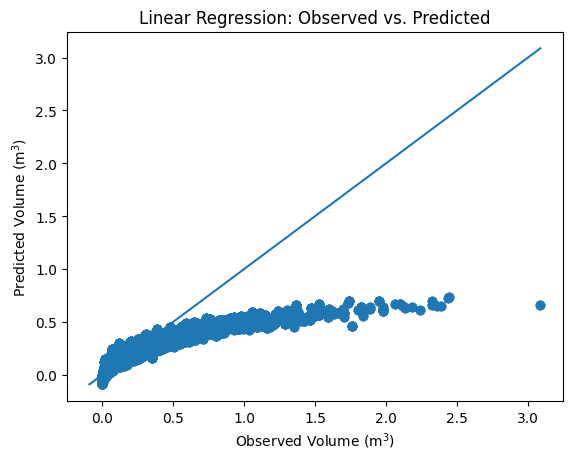

In [48]:
plt.figure()
plt.scatter(y_test, lr_pred)
plt.xlabel("Observed Volume (m$^3$)")
plt.ylabel("Predicted Volume (m$^3$)")
plt.title("Linear Regression: Observed vs. Predicted")

min_val = min(y_test.min(), lr_pred.min())
max_val = max(y_test.max(), lr_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.show()

#### RandomForest Regression Model

In [49]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

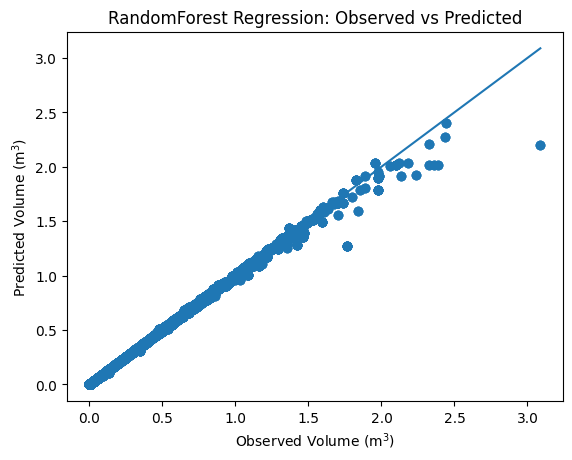

In [50]:
plt.figure()
plt.scatter(y_test, rf_pred)
plt.xlabel("Observed Volume (m$^3$)")
plt.ylabel("Predicted Volume (m$^3$)")
plt.title("RandomForest Regression: Observed vs Predicted")

min_val = min(y_test.min(), rf_pred.min())
max_val = max(y_test.max(), rf_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.show()


#### XGBoost Regression Model

In [53]:
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1)
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

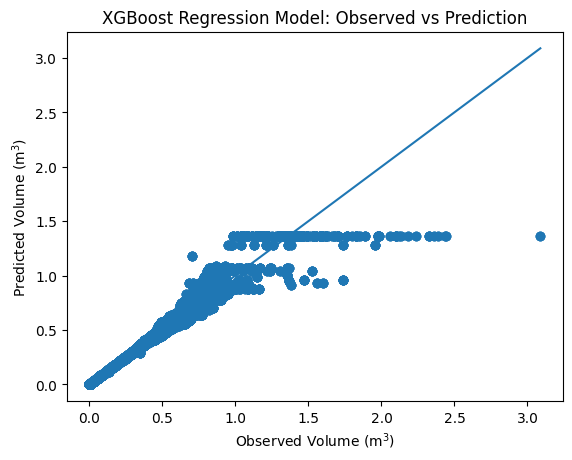

In [54]:
plt.figure()
plt.scatter(y_test, xgb_pred)
plt.xlabel("Observed Volume (m$^3$)")
plt.ylabel("Predicted Volume (m$^3$)")
plt.title("XGBoost Regression Model: Observed vs Prediction")

min_val = min(y_test.min(), xgb_pred.min())
max_val = max(y_test.max(), xgb_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.show()

#### Support Vector Regression Model

In [55]:
svr = SVR(kernel='rbf')
svr.fit(X_train_scaled, y_train)

svr_pred = svr.predict(X_test_scaled)

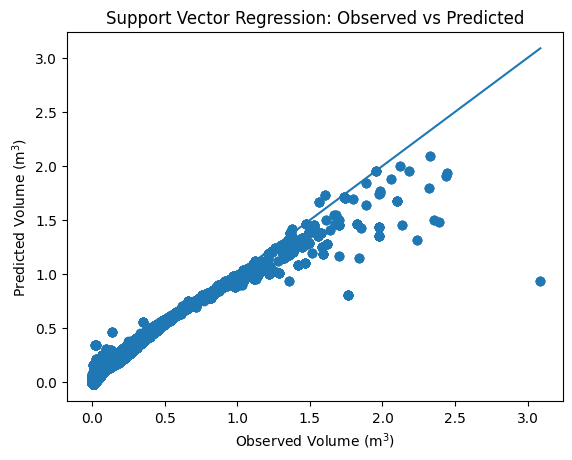

In [56]:
plt.figure()
plt.scatter(y_test, svr_pred)
plt.xlabel("Observed Volume (m$^3$)")
plt.ylabel("Predicted Volume (m$^3$)")
plt.title("Support Vector Regression: Observed vs Predicted")

min_val = min(y_test.min(), svr_pred.min())
max_val = max(y_test.max(), svr_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.show()

#### Evaluate the Models

In [58]:
# Evaluate the Linear Regression Model
print("LINEAR REGRESSION")
print('-'*30)
rmse_lr = np.sqrt(mean_squared_error(y_test, lr_pred))
mae_lr = mean_absolute_error(y_test, lr_pred)
r2_lr = r2_score(y_test, lr_pred)
print(f"RMSE: {rmse_lr}\nMAE: {mae_lr}\nR2: {r2_lr}")
print()

# Evaluate the RandomForestRegression Model
print("RANDOMFOREST REGRESSION")
print("-"*30)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
mae_rf = mean_absolute_error(y_test, rf_pred)
r2_rf = r2_score(y_test, rf_pred)
print(f"RMSE: {rmse_rf}\nMAE: {mae_rf}\nR2: {r2_rf}")
print()

# Evaluate the XGBoost Model
print("XGBOOST MODEL")
print("-"*30)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))
mae_xgb = mean_absolute_error(y_test, xgb_pred)
r2_xgb = r2_score(y_test, xgb_pred)
print(f"RMSE: {rmse_xgb}\nMAE: {mae_xgb}\nR2: {r2_xgb}")
print()

# EValuate the Support Vector Regression Model
print("SUPPORT VECTOR REGRESSION MODEL")
print("-"*30)
rmse_svr = np.sqrt(mean_squared_error(y_test, svr_pred))
mae_svr = mean_absolute_error(y_test, svr_pred)
r2_svr = r2_score(y_test, svr_pred)
print(f"RMSE: {rmse_svr}\nMAE: {mae_svr}\nR2: {r2_svr}")

LINEAR REGRESSION
------------------------------
RMSE: 0.07609862062625325
MAE: 0.04353271974987098
R2: 0.7325313163949452

RANDOMFOREST REGRESSION
------------------------------
RMSE: 0.004977106021894177
MAE: 0.0004644493799152776
R2: 0.9988558758439451

XGBOOST MODEL
------------------------------
RMSE: 0.02016552846520069
MAE: 0.003753046755051825
R2: 0.9812181405501477

SUPPORT VECTOR REGRESSION MODEL
------------------------------
RMSE: 0.07312552522238519
MAE: 0.06833295048206008
R2: 0.7530225128926793
